# Exercício 1 — Nuvens de pontos: geometria e dispersão em 2D

A ideia aqui é gerar nuvens de pontos 2D e **medir** o quanto elas se misturam antes
de pensar em qualquer rede. Uso a mesma seed do começo ao fim:
`rng = np.random.default_rng(42)`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # mesma seed em todo o notebook

# identidade visual dos meus gráficos: paleta fixa + eixos limpos
CORES = ["#E8A13D", "#C75146", "#6B8F3D", "#33658A"]  # âmbar, telha, oliva, aço
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=CORES),
    "figure.dpi": 110,
})

## A — Gerar as nuvens

Parâmetros do enunciado: 4 classes, 100 pontos cada, com média e desvio-padrão
**por eixo** (nada de gaussiana esférica aqui).

In [2]:
MEDIAS = np.array([[2, 3], [5, 6], [8, 1], [15, 4]], dtype=float)
DESVIOS = np.array([[0.8, 2.5], [1.2, 1.9], [0.9, 0.9], [0.5, 2.0]], dtype=float)

# 100 pontos por classe: cada eixo com sua média e desvio próprios
X1 = np.vstack([rng.normal(MEDIAS[k], DESVIOS[k], size=(100, 2)) for k in range(4)])
y1 = np.repeat(np.arange(4), 100)
print("dataset:", X1.shape, "| classes:", np.bincount(y1))

dataset: (400, 2) | classes: [100 100 100 100]


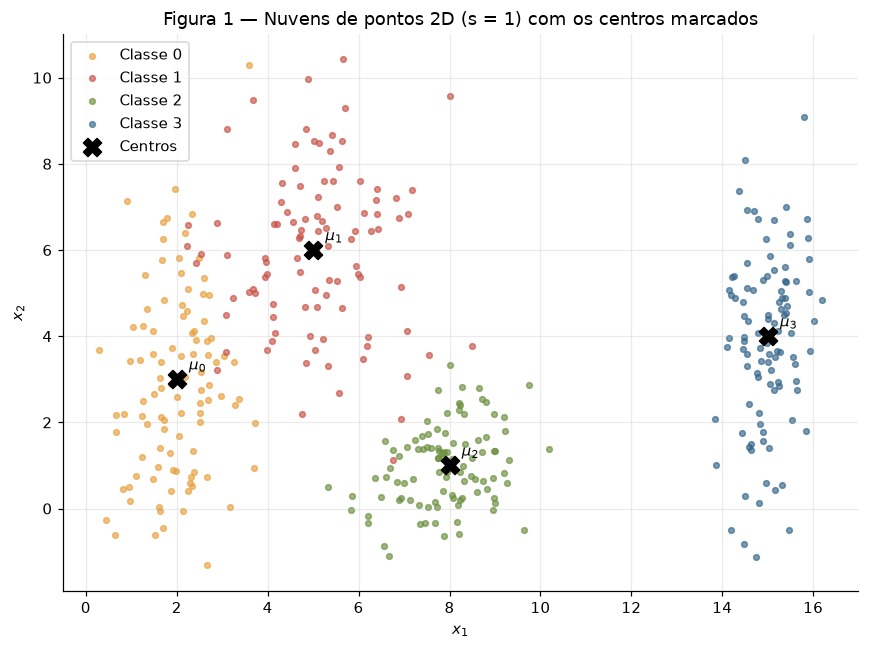

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
for k in range(4):
    ax.scatter(X1[y1 == k, 0], X1[y1 == k, 1], s=14, alpha=0.65, color=CORES[k],
               label=f"Classe {k}")
ax.scatter(MEDIAS[:, 0], MEDIAS[:, 1], marker="X", s=140, color="black", zorder=5,
           label="Centros")
for k in range(4):
    ax.annotate(f"$\\mu_{k}$", MEDIAS[k], textcoords="offset points", xytext=(8, 6))
ax.set_title("Figura 1 — Nuvens de pontos 2D (s = 1) com os centros marcados")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
plt.tight_layout()
plt.show()

O que me chama atenção de cara: a classe 0 ($\sigma = [0.8,\ 2.5]$) é um charuto
vertical apontando direto para a classe 1, enquanto a classe 2 é quase redonda e a
classe 3, lá em $\mu = [15, 4]$, vive isolada das outras.

## B — Mais ou menos espalhadas

Agora as mesmas 4 classes, geradas 4 vezes, multiplicando **todos** os desvios por
$s \in \{0.5,\ 1.0,\ 2.0,\ 4.0\}$. As médias não mudam — só o espalhamento. Para
$s = 1$ reutilizo o dataset do item A (mesma amostra).

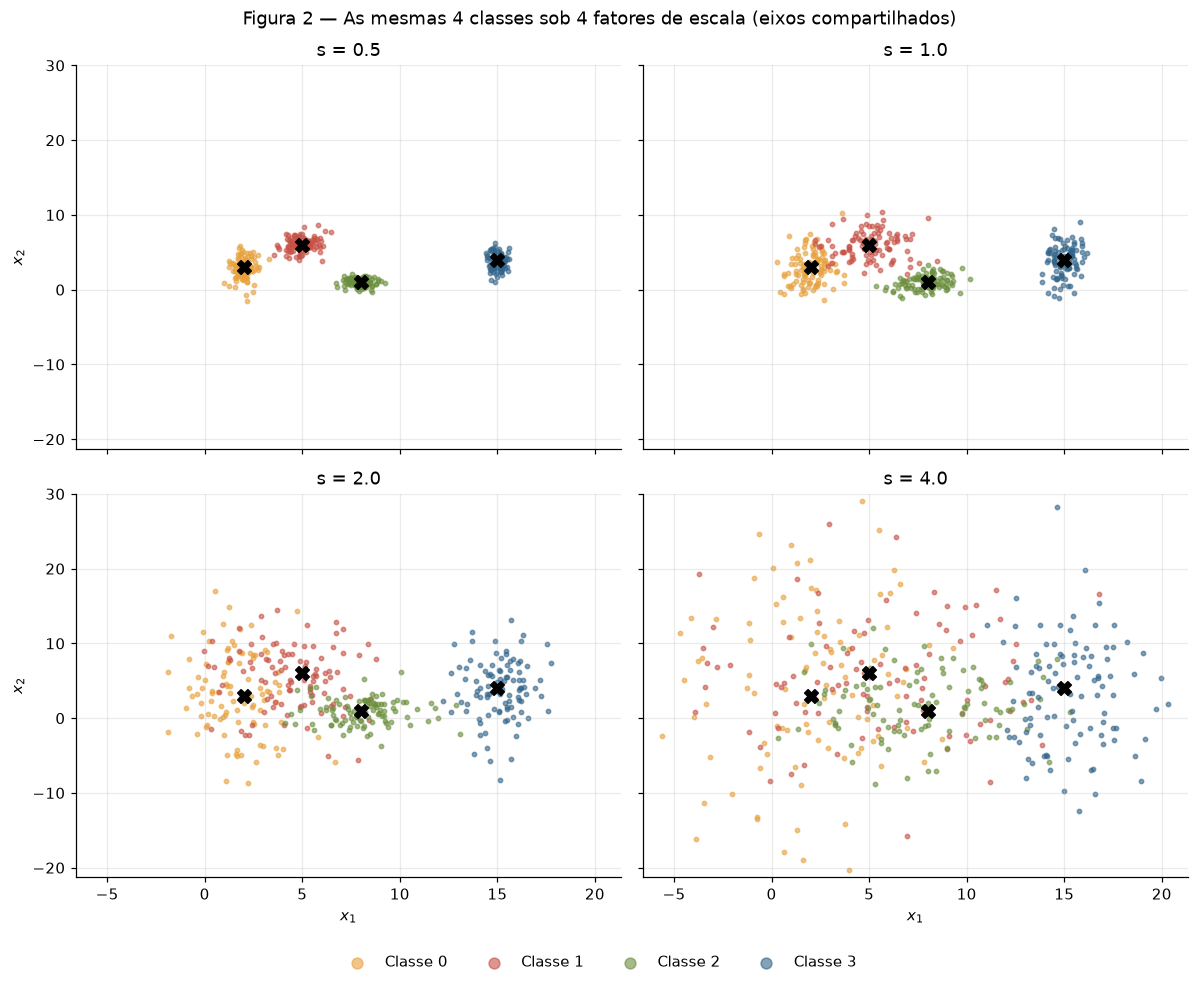

In [4]:
escalas = [0.5, 1.0, 2.0, 4.0]
dados = {1.0: (X1, y1)}  # s = 1 é o dataset do item A
for s in [0.5, 2.0, 4.0]:
    X = np.vstack([rng.normal(MEDIAS[k], DESVIOS[k] * s, size=(100, 2)) for k in range(4)])
    dados[s] = (X, np.repeat(np.arange(4), 100))

# limites de eixo iguais nos 4 subplots — senão a comparação mente
todos = np.vstack([dados[s][0] for s in escalas])
xlim = (todos[:, 0].min() - 1, todos[:, 0].max() + 1)
ylim = (todos[:, 1].min() - 1, todos[:, 1].max() + 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, s in zip(axes.ravel(), escalas):
    X, y = dados[s]
    for k in range(4):
        ax.scatter(X[y == k, 0], X[y == k, 1], s=8, alpha=0.6, color=CORES[k],
                   label=f"Classe {k}" if s == 0.5 else None)
    ax.scatter(MEDIAS[:, 0], MEDIAS[:, 1], marker="X", s=80, color="black", zorder=5)
    ax.set_title(f"s = {s}")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
for ax in axes[-1]:
    ax.set_xlabel("$x_1$")
for ax in axes[:, 0]:
    ax.set_ylabel("$x_2$")
fig.suptitle("Figura 2 — As mesmas 4 classes sob 4 fatores de escala (eixos compartilhados)")
fig.legend(loc="lower center", ncol=5, frameon=False, markerscale=2.5)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### Razão de separação $r_{ij}$ em $s = 1$

$$ r_{ij} = \frac{\lVert \mu_i - \mu_j \rVert}{\bar{\sigma}_i + \bar{\sigma}_j},
\qquad \bar{\sigma}_k = \frac{\sigma_{k,x} + \sigma_{k,y}}{2} $$

In [5]:
sigma_barra = DESVIOS.mean(axis=1)  # dispersão média de cada classe

linhas = []
for i in range(4):
    for j in range(i + 1, 4):
        dist = np.linalg.norm(MEDIAS[i] - MEDIAS[j])
        r = dist / (sigma_barra[i] + sigma_barra[j])
        linhas.append({"par": f"({i}, {j})", "‖μi − μj‖": round(dist, 3),
                       "σ̄i + σ̄j": round(sigma_barra[i] + sigma_barra[j], 2),
                       "r_ij": round(r, 3)})
tabela_r = pd.DataFrame(linhas)
print(tabela_r.to_string(index=False))

menor = tabela_r.loc[tabela_r["r_ij"].idxmin()]
print(f"\nMenor razão: par {menor['par']} com r = {menor['r_ij']}")
print(f"Como r_ij ∝ 1/s, em s = 2 esse valor vira {menor['r_ij'] / 2:.3f}")

   par  ‖μi − μj‖  σ̄i + σ̄j  r_ij
(0, 1)      4.243       3.20 1.326
(0, 2)      6.325       2.55 2.480
(0, 3)     13.038       2.90 4.496
(1, 2)      5.831       2.45 2.380
(1, 3)     10.198       2.80 3.642
(2, 3)      7.616       2.15 3.542

Menor razão: par (0, 1) com r = 1.326
Como r_ij ∝ 1/s, em s = 2 esse valor vira 0.663


O par mais apertado é o **(0, 1)**, com $r_{01} = 1.326$ — todos os outros têm
$r_{ij} \geq 2.38$. E aqui está o pulo do gato: como as médias não mudam com $s$,
vale $r_{ij} \propto 1/s$. Então em $s = 2$ o menor valor vira
$1.326 / 2 = \mathbf{0.663}$, sem eu precisar gerar um ponto sequer.

### Mixing rate

Fração de pontos cujo centro mais próximo (entre as 4 médias teóricas) **não** é o da
própria classe. É só comparar distâncias — nada é treinado.

mixing rate (s = 0.5): 0.0000  (0/400 pontos)
mixing rate (s = 1.0): 0.0500  (20/400 pontos)
mixing rate (s = 2.0): 0.1925  (77/400 pontos)
mixing rate (s = 4.0): 0.4825  (193/400 pontos)


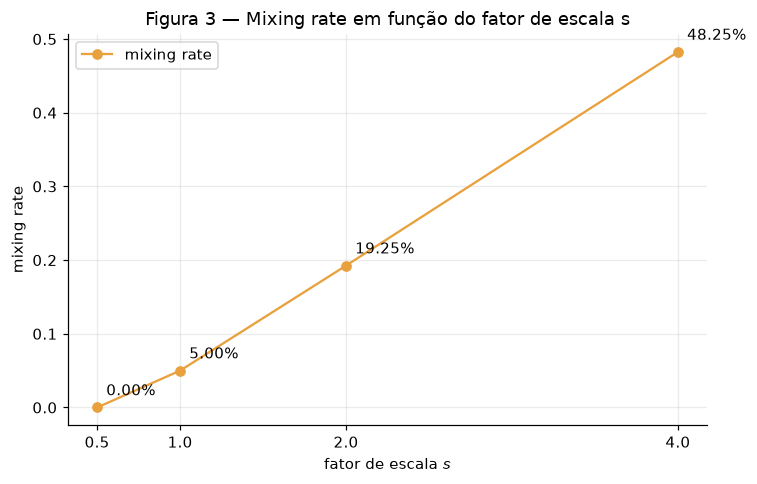

In [6]:
mistura = {}
for s in escalas:
    X, y = dados[s]
    d2 = ((X[:, None, :] - MEDIAS[None, :, :]) ** 2).sum(axis=2)  # (400, 4)
    mistura[s] = float((d2.argmin(axis=1) != y).mean())
    print(f"mixing rate (s = {s}): {mistura[s]:.4f}  ({int(mistura[s] * 400)}/400 pontos)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(escalas, [mistura[s] for s in escalas], marker="o", color=CORES[0],
        label="mixing rate")
for s in escalas:
    ax.annotate(f"{mistura[s]:.2%}", (s, mistura[s]), textcoords="offset points",
                xytext=(6, 8))
ax.set_title("Figura 3 — Mixing rate em função do fator de escala s")
ax.set_xlabel("fator de escala $s$")
ax.set_ylabel("mixing rate")
ax.set_xticks(escalas)
ax.legend()
plt.tight_layout()
plt.show()

Deu: **0.00%** ($s{=}0.5$), **5.00%** ($s{=}1$), **19.25%** ($s{=}2$),
**48.25%** ($s{=}4$).

**A partir de que escala as retas param de funcionar?** A partir de $s = 2$. Em
$s = 1$ a mistura é de 5% e mora quase toda no par (0, 1) — um conjunto de retas
ainda dá conta do resto. Em $s = 2$ a mistura salta para 19.25% e o menor $r_{ij}$
cai para **0.663**: a distância entre os centros 0 e 1 fica *menor* que a soma das
dispersões médias, ou seja, as nuvens se atravessam e não existe arranjo de retas que
escape de uma fração grande de erro. Em $s = 4$ ($r_{01} = 0.33$), quase metade dos
pontos já está mais perto de um centro alheio.

## C — Análise

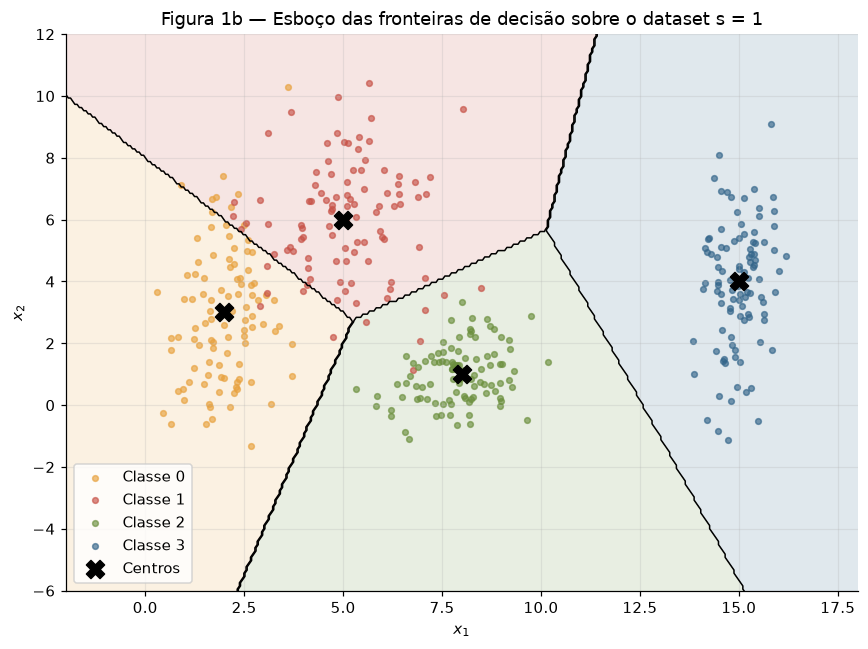

In [7]:
# Meu esboço das fronteiras: divido o plano pela regra do centro mais próximo
# (fronteiras retas — aproximação do que uma rede pequena aprenderia)
gx, gy = np.meshgrid(np.linspace(*xlim, 500), np.linspace(*ylim, 500))
grade = np.stack([gx.ravel(), gy.ravel()], axis=1)
Z = ((grade[:, None, :] - MEDIAS[None, :, :]) ** 2).sum(axis=2).argmin(axis=1).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(gx, gy, Z, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], colors=CORES, alpha=0.15)
ax.contour(gx, gy, Z, levels=[0.5, 1.5, 2.5], colors="black", linewidths=1)
for k in range(4):
    ax.scatter(X1[y1 == k, 0], X1[y1 == k, 1], s=14, alpha=0.65, color=CORES[k],
               label=f"Classe {k}")
ax.scatter(MEDIAS[:, 0], MEDIAS[:, 1], marker="X", s=140, color="black", zorder=5,
           label="Centros")
ax.set_title("Figura 1b — Esboço das fronteiras de decisão sobre o dataset s = 1")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_xlim(-2, 18)
ax.set_ylim(-6, 12)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

**Sobreposição em $s = 1$.** A única briga de verdade é entre as classes 0 e 1
($r_{01} = 1.326$): a cauda vertical da 0 invade a nuvem da 1. Os outros pares têm
$r_{ij} \geq 2.38$ e mal se encostam.

**Uma única fronteira linear resolve?** Não — uma reta corta o plano em só duas
regiões, e eu tenho 4 classes. **Um conjunto de retas?** Quase: a partição da
Figura 1b acerta 95% dos pontos; os 5% que sobram estão na zona 0–1, onde as
distribuições se sobrepõem de fato.

**O esboço.** As fronteiras da Figura 1b são o que eu espero de uma rede treinada:
cortes aproximadamente retos entre centros vizinhos. Com mais capacidade ela curvaria
o corte 0–1 (a classe 0 é bem mais esticada em $x_2$ que a 1), mas nenhuma fronteira
elimina a região onde as duas densidades se misturam.

**Ligando com o item B.** Quanto maior a dispersão, maior a área onde as densidades
das classes se sobrepõem — e ali qualquer classificador erra, por melhor que seja.
Esse é o **erro irredutível**, que pertence aos dados: a mixing rate de
5% → 19% → 48% é exatamente essa região crescendo.

---

> **O que eu tiro daqui:** a dificuldade de classificar é geométrica e dá para medir
> antes de treinar qualquer coisa. O que importa é a distância entre centros
> **relativa à dispersão** ($r_{ij}$), não a absoluta — e quando $r_{ij}$ cai abaixo
> de ~1, as nuvens se atravessam e nasce um erro que nenhuma arquitetura remove.